In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts
df=pd.read_csv('titanic.csv')


In [2]:
df.shape

(891, 12)

In [3]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

# Measures of central tendency

# MEAN

In [6]:

# Mean age of all passengers
mean_age=df.Age.mean().round(2)
print(f"mean age is {mean_age}.")

# Mean fare
mean_fare=df.Fare.mean().round(2)
print(f"Average fare paid by the passengers was ${mean_fare}.")


mean age is 29.7.
Average fare paid by the passengers was $32.2.


 # MEDIAN

In [7]:
# Median Age
Median_age=df.Age.median()
print(f"The median age for the passengers was {Median_age:.2f}.")

# Median Fare
Median_Fare=df.Fare.median()
print(f"The median fare for the passengers was {Median_Fare:.2f}.")


The median age for the passengers was 28.00.
The median fare for the passengers was 14.45.


# MODE

In [8]:
# Most  common pasengers class
mode_class=df. Pclass.mode()[0]
print(f" Most common class was {mode_class}.")

# Most  common embarkation port
mode_class = df. Embarked .mode()[0]
print(f" Most Embarkation port  was {mode_class}.")

# Most  common Age
mode_class = df. Age.mode()[0]
print(f" Most Age  was {mode_class}.")


 Most common class was 3.
 Most Embarkation port  was S.
 Most Age  was 24.0.


# MEASURES OF SPREAD

# variance & Std

In [9]:
std_age=df.Age.std()
var_age=df.Age.var()
av_age=df.Age.mean()

print(f"Age mean: {av_age:.2f}")
print(f"Standard deviation: {std_age:.2f}")
print(f"Variance: {var_age:.2f}")

# Most people are between
# 29.70+14.53=44.23
                        
# 29.70-14.53=15.17


Age mean: 29.70
Standard deviation: 14.53
Variance: 211.02


# Range & IQR (Interquartile Range)

In [10]:
# Range
age_range=df.Age.max()-df.Age.min()
print(f"The age range Range{age_range}")

# Percentiles
p25=df.Age.quantile(0.25)
p50=df.Age.quantile(0.50)
p75=df.Age.quantile(0.75)
iqr=p75-p25

print(f" 25th percentile: {p25:.1f}")
print(f" 50th percentile: {p50:.1f}")
print(f" 75th percentile: {p75:.1f}")
print(f"interquantile range: {iqr:1f}")


The age range Range79.58
 25th percentile: 20.1
 50th percentile: 28.0
 75th percentile: 38.0
interquantile range: 17.875000


# DISTRIBUTION

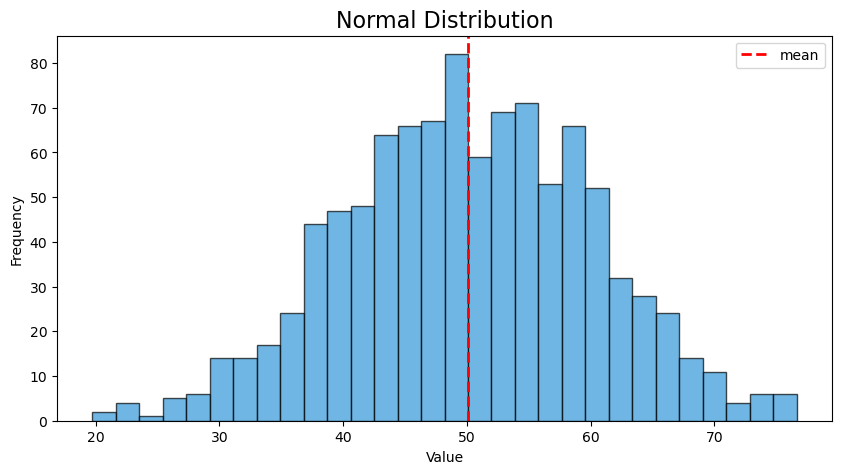

In [11]:
# Generate a normal distribution
normal_data=np.random.normal(
    loc=50,
    scale=10,
    size=1000
)
plt.figure(figsize=(10,5))
plt.hist(normal_data, bins=30,
         color="#3498db", edgecolor="black",
         alpha=0.7)
plt.axvline(np.mean(normal_data),
         color="red", linestyle="--",
         linewidth=2, label="mean")
plt.title("Normal Distribution", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

         

         

           
    
    
    

# Skewness

In [12]:
fare_skew=df.Fare.skew()
age_skew=df.Age.skew()

print(f"Fare skew {fare_skew:.2f}")
print(f"Age skew {age_skew:.2f}")

Fare skew 4.79
Age skew 0.39


<function matplotlib.pyplot.show(close=None, block=None)>

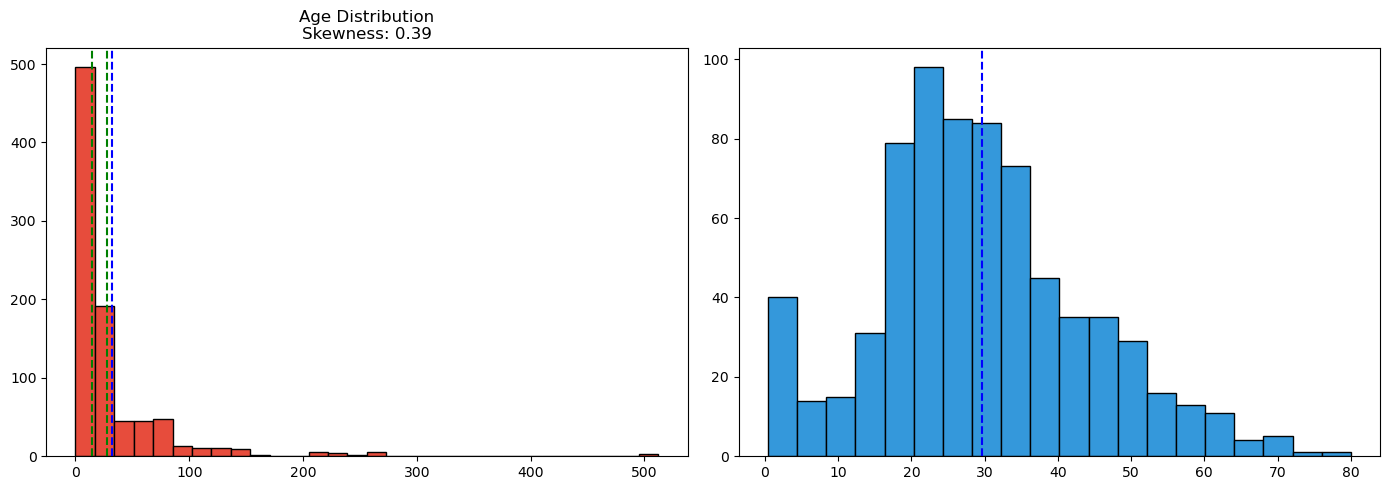

In [13]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

# Fare Distribution
axes[0].hist(df['Fare'],bins=30,
             color='#e74c3c',edgecolor='black')
axes[0].axvline(df['Fare'].mean(),
                color='blue',linestyle='--',
                label=f"mean:${df['Fare'].mean():.0f}")
axes[0].axvline(df['Fare'].median(),
                color='green',linestyle='--',
                label=f"Median:${df['Fare'].median():.0f}")
axes[0].set_title(f"Fare Distribution\nSkewness: {df["Fare"].skew():.2f}")
axes[0].legend


# Age Distribution
axes[1].hist(df['Age'].dropna(),bins=20,
             color='#3498db',edgecolor='black')
axes[1].axvline(df['Age'].mean(),
                color='blue',linestyle='--',
                label=f"mean:${df['Age'].mean():.1f}")
axes[0].axvline(df['Age'].median(),
                color='green',linestyle='--',
                label=f"Median:{df['Age'].median():.1f}")
axes[0].set_title(f"Age Distribution\nSkewness: {df["Age"].skew():.2f}")

plt.tight_layout()
plt.show
    

# Detecting Outliers

In [14]:
Q1=df.Fare.quantile(0.25)
Q3=df.Fare.quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=df[(df["Fare"]<lower_bound)|
         (df["Fare"]>upper_bound)]

print(f"Q1:{Q1:.2F}")
print(f"Q3:{Q3:.2F}")
print(f"IQR:{IQR:.2F}")
print(f"Lower Bound:{lower_bound:.2f}")
print(f"Upper Bound:{upper_bound:.2f}")
print(f"Number of Outliers:{len(outliers)}")

         


Q1:7.91
Q3:31.00
IQR:23.09
Lower Bound:-26.72
Upper Bound:65.63
Number of Outliers:116


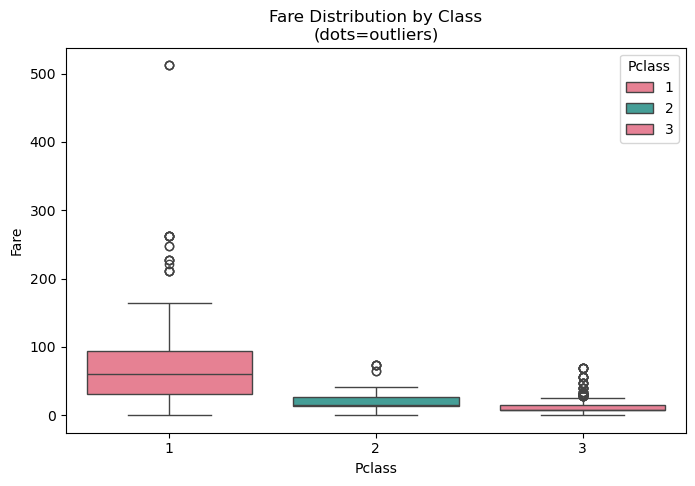

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Pclass",y="Fare",hue="Pclass", palette="husl")
plt.title(f"Fare Distribution by Class\n(dots=outliers)")
plt.show()

In [16]:
df.to_csv("titanic_statistical_analysis.csv" ,index=False)
print('clean file saved!')

clean file saved!
